In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while project_root.name != 'python' and project_root.parent != project_root:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

## Downloading the data

In [2]:
from data import download_tickers_history

TRADING_DAYS_PER_YEAR = 252

# set the date range for the historic data
start_date = datetime(year=2022, month=1, day=1)
end_date = datetime(year=2026, month=1, day=1)
tickers = ['NVDA', 'AAPL', 'PLTR', 'DKNG', 'CAT', 'INTC', 'AMZN', 'TSLA', 'GOOG', 'MSFT']
history = download_tickers_history(start_date, end_date, tickers)

history.head()


Ticker            TSLA                                                 \
Price             Open        High         Low       Close     Volume   
Date                                                                    
2022-01-03  382.583344  400.356659  378.679993  399.926666  103931400   
2022-01-04  396.516663  402.666656  374.350006  383.196655  100248300   
2022-01-05  382.216675  390.113342  360.336670  362.706665   80119800   
2022-01-06  359.000000  362.666656  340.166656  354.899994   90336600   
2022-01-07  360.123322  360.309998  336.666656  342.320007   84164700   

Ticker            AMZN                                                ...  \
Price             Open        High         Low       Close    Volume  ...   
Date                                                                  ...   
2022-01-03  167.550003  170.703506  166.160507  170.404495  63520000  ...   
2022-01-04  170.438004  171.399994  166.349503  167.522003  70726000  ...   
2022-01-05  166.882996  167.126495  164.356995  164.356995  64302000  ...   
2022-01-06  163.450500  164.800003  161.936996  163.253998  51958000  ...   
2022-01-07  163.839005  165.243500  162.031006  162.554001  46606000  ...   

Ticker           PLTR                                                    CAT  \
Price            Open       High        Low      Close    Volume        Open   
Date                                                                           
2022-01-03  18.360001  18.569000  17.860001  18.530001  34283600  191.295646   
2022-01-04  18.610001  18.840000  17.790001  18.170000  39643200  192.172197   
2022-01-05  18.030001  18.568001  16.870001  16.959999  58445900  201.306540   
2022-01-06  16.870001  17.180000  16.055000  16.740000  49737100  204.360568   
2022-01-07  16.700001  17.330000  16.475000  16.559999  37989300  205.292443   

Ticker                                                   
Price             High         Low       Close   Volume  
Date                                                     
2022-01-03  192.467431  189.883973  190.991165  2055600  
2022-01-04  201.989328  191.858495  201.214294  5242300  
2022-01-05  206.085940  201.306540  202.755127  5378200  
2022-01-06  205.486218  201.195828  204.821899  3913200  
2022-01-07  208.494084  205.043321  206.851746  3673400  

[5 rows x 50 columns]

## The essence of the approach

The Ledoit-Wolf shrinkage method is needed to refine the noisy evaluation of covariate matrix $\Sigma$: with a large number of assets $N$ relative to the sample length of $T$, the sample covariate matrix is either warped or contains a lot of noise.

The sample covariance matrix $S = \frac{1}{T-1} X^T X$ is unbalanced but has a high error dispersion at $N / T = const$. If we invert $S$ in the the _GMF_ optimizer, small eigenvalues (noise) are inflated, distorting the weights of the portfolio.

### Method idea:
Squeeze a noisy sample matrix $S$ toward a structured, stable target matrix $F$:
$$\Sigma_{\text{LW}} = (1 - \delta) S + \delta F,$$
where:
* $S$ - sample covariance matrix;
* $F$ - structured target matrix. It is often used Constant Correlation Model, where the mean variance is retained and all pair correlations are replaced by the sample's mean correlation, or a diagonal matrix (zero correlations);
* $\delta \in [0, 1]$ - shrinkage intensity, which can be found analitically by minimizing Mean Square Error in Frobenius norm $\min_{\delta} E\left[ \Vert{}\Sigma_{\text{LW}} - \Sigma_{\text{true}}\Vert{}_F^2 \right]$, and has a closed-form solution $\delta^*$ :$$\delta^* = \frac{\text{Variance of the Sample Covariances } S}{\text{Squared Distance between sample } S \text{ and target matrix } F}$$

In [3]:
from numpy import linalg as lg
from data.processors import log_returns

# Sample covariance matrix
returns = log_returns(history)
sample_cov = returns.cov() * TRADING_DAYS_PER_YEAR # type: ignore

# Build structured target matrix (FIX)
num_assets = sample_cov.columns.nunique()
rho = np.diag(sample_cov).mean()
target_matrix = np.diag(np.diag(sample_cov))
for i in range(0, num_assets):
    for j in range(0, num_assets):
        if i != j:
            target_matrix[i, j] = rho

# Find Shrinkage intencity coefficient
shrinkage_intensity = sample_cov.std().sum() / lg.norm(sample_cov - target_matrix) ** 2

cov_shrunk = (1 - shrinkage_intensity) * sample_cov + shrinkage_intensity * target_matrix
cov_shrunk


Ticker,TSLA,AMZN,GOOG,NVDA,INTC,DKNG,AAPL,MSFT,PLTR,CAT
Ticker,,,,,,,,,,
TSLA,0.380090,0.141508,0.127551,0.177341,0.133003,0.179775,0.128376,0.115518,0.211997,0.105069
AMZN,0.141508,0.139526,0.119488,0.145316,0.116167,0.142167,0.107518,0.112656,0.155385,0.091772
GOOG,0.127551,0.119488,0.105873,0.131501,0.103099,0.117317,0.103551,0.104364,0.130821,0.086751
NVDA,0.177341,0.145316,0.131501,0.285894,0.138441,0.170721,0.121157,0.130091,0.198606,0.106365
INTC,0.133003,0.116167,0.103099,0.138441,0.243328,0.128953,0.102810,0.100846,0.140156,0.098203
DKNG,0.179775,0.142167,0.117317,0.170721,0.128953,0.408075,0.112791,0.112838,0.209509,0.099494
AAPL,0.128376,0.107518,0.103551,0.121157,0.102810,0.112791,0.080696,0.098971,0.121204,0.086375
MSFT,0.115518,0.112656,0.104364,0.130091,0.100846,0.112838,0.098971,0.071434,0.123230,0.083548
PLTR,0.211997,0.155385,0.130821,0.198606,0.140156,0.209509,0.121204,0.123230,0.456127,0.109295


Now find the shrinkage_intencity and the shrunk assets covariance matrix via `sklearn` tools

In [4]:
from sklearn.covariance import LedoitWolf

returns = np.asarray(log_returns(history))
lw = LedoitWolf()
lw.fit(returns)

cov_shrunk = lw.covariance_ * TRADING_DAYS_PER_YEAR
shrinkage_intensity = lw.shrinkage_ # optimal delta
cov_shrunk


array([[0.37762009, 0.10573227, 0.08641881, 0.1553164 , 0.09396317,
        0.15868463, 0.08756013, 0.06976778, 0.20327283, 0.05530852],
       [0.10573227, 0.14056241, 0.07526129, 0.11100086, 0.07066592,
        0.10664326, 0.05869684, 0.06580667, 0.12493437, 0.03690785],
       [0.08641881, 0.07526129, 0.10739998, 0.09188372, 0.05258193,
        0.07225716, 0.0532079 , 0.05433333, 0.09094366, 0.02996037],
       [0.1553164 , 0.11100086, 0.09188372, 0.28479694, 0.10148771,
        0.146157  , 0.07757118, 0.08993347, 0.18474303, 0.0571011 ],
       [0.09396317, 0.07066592, 0.05258193, 0.10148771, 0.24285141,
        0.08835837, 0.05218211, 0.04946483, 0.10386155, 0.04580711],
       [0.15868463, 0.10664326, 0.07225716, 0.146157  , 0.08835837,
        0.40519755, 0.06599386, 0.06605856, 0.19983035, 0.04759419],
       [0.08756013, 0.05869684, 0.0532079 , 0.07757118, 0.05218211,
        0.06599386, 0.08259031, 0.04687022, 0.07763518, 0.0294404 ],
       [0.06976778, 0.06580667, 0.0543333

#### GMF Optimization with Ledouit-Wolf shrinkage model and data visualization

Find the Efficient Frontier distribution

In [10]:
from src.portfolio import optimize_portfolio, get_risk_free_rate

optimum_df = optimize_portfolio(tickers_df=history, rf_base='T_BILLS', opt_models=['LEDOIT_WOLF'])
risk_free_rate = get_risk_free_rate('T_BILLS', start_date, end_date)
risk_free_rate

0.04190200400801603

Find the max Sharpe

In [11]:
from src.portfolio import find_max_sharpe

(max_sharpe, stocks_w) = find_max_sharpe(
    tickers_df=history,
    rf_base='T_BILLS',
    opt_models=['LEDOIT_WOLF'])

exact_max_ret = max_sharpe.tangency_return
exact_max_vol = max_sharpe.tangency_vol
exact_max_sharpe = max_sharpe.max_sharpe

print(f"Exact Max Sharpe Ratio: {max_sharpe.max_sharpe:.4f}")
print(f"Exact Tangency Return: {exact_max_ret:.2%}")
print(f"Exact Tangency Volatility: {exact_max_vol:.2%}")

print("Exact optimum stocks distribution:")
stocks_w

Exact Max Sharpe Ratio: 0.9971
Exact Tangency Return: 41.17%
Exact Tangency Volatility: 37.09%
Exact optimum stocks distribution:


,TSLA,AMZN,GOOG,NVDA,INTC,DKNG,AAPL,MSFT,PLTR,CAT
0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,0.0,27.0,40.0


Visualize the data

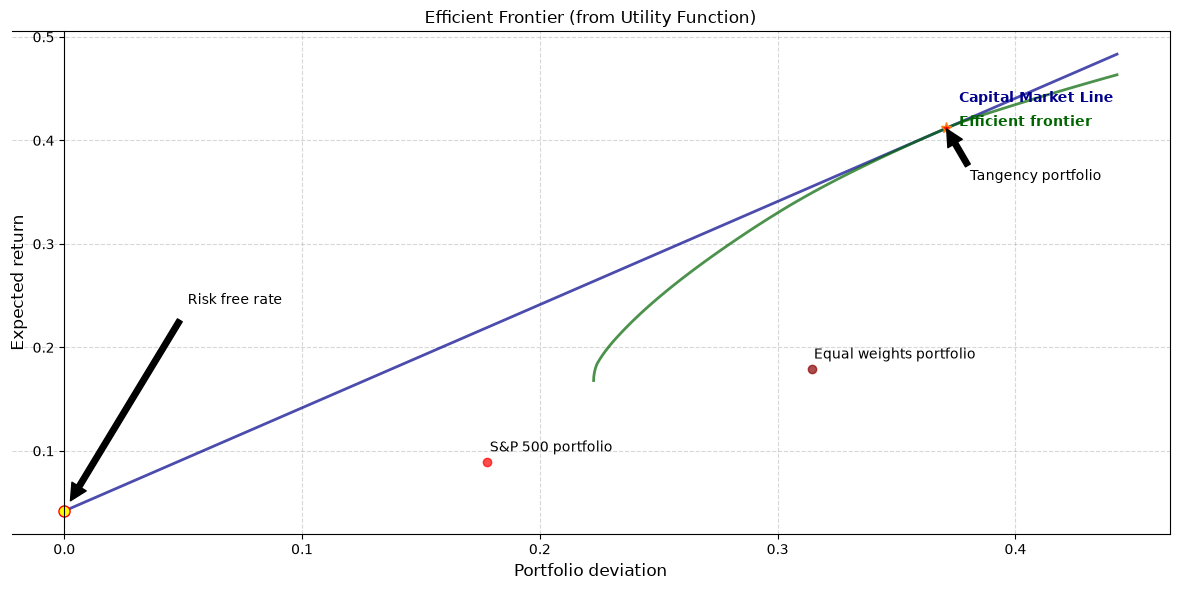

In [12]:
from data.processors import log_returns

fig, ax = plt.subplots(figsize=(12, 6))

vol = optimum_df['vol']
sharpe = optimum_df['sharpe']
returns = optimum_df['return']
max_vol = vol.max()
max_sharpe = sharpe.max()
max_sharpe_ind = sharpe.idxmax()
log_ret = log_returns(history)
expected_returns = log_ret.mean() * TRADING_DAYS_PER_YEAR

# capital distribution line
cal_x = np.linspace(0, max_vol, 100)
cal_y = max_sharpe * cal_x + risk_free_rate

ax.plot(
    cal_x,
    cal_y,
    color='darkblue',
    alpha=0.7,
    linewidth=2, 
)
ax.spines['left'].set_position('zero')
x_label = max_vol * 0.85
y_label = max_sharpe * x_label + risk_free_rate

# Add text on the plot
ax.text(
    x_label,
    y_label + 0.02,
    'Capital Market Line',
    color='darkblue',
    fontweight='bold'
)

# mark risk free rate point
plt.plot(0, risk_free_rate, marker="o", markersize=8, markeredgecolor="red", markerfacecolor="yellow")
plt.annotate(
    'Risk free rate',
    xy=(0, risk_free_rate),
    xytext=(risk_free_rate + 0.01, risk_free_rate + 0.2),
    arrowprops=dict(facecolor='black', shrink=0.05)
)

# effective frontier
ef_x = vol
ef_y = returns
ax.plot(
    ef_x,
    ef_y,
    color='darkgreen',
    alpha=0.7,
    linewidth=2,
)

# equal weights portfolio
x0 = np.ones(num_assets) / num_assets
def_x = float(np.sqrt(x0.T @ cov_shrunk @ x0))
def_y = np.dot(x0, expected_returns)
ax.scatter(
    def_x,
    def_y,
    color='darkred',
    alpha=0.7,
)
plt.text(def_x + 0.001, def_y + 0.01, 'Equal weights portfolio')

# S&P 500 portfolio
sp500_df = download_tickers_history(start_date, end_date, ['^GSPC'])
sp500_log_ret = log_returns(sp500_df)

sp500_x = sp500_log_ret.std().iloc[0] * np.sqrt(TRADING_DAYS_PER_YEAR)
sp500_y = sp500_log_ret.mean().iloc[0] * TRADING_DAYS_PER_YEAR
ax.scatter(
    sp500_x,
    sp500_y,
    color='red',
    alpha=0.7,
)
plt.text(sp500_x + 0.001, sp500_y + 0.01, 'S&P 500 portfolio')

x_label = max_vol * 0.85
y_label = returns.max() * 0.85
# Add text on the plot
ax.text(
    x_label,
    y_label + 0.02,
    'Efficient frontier',
    color='darkgreen',
    fontweight='bold'
)

# mark the tangency portfolio point
plt.plot(exact_max_vol, exact_max_ret, marker="*", markersize=8, markerfacecolor="red")
plt.annotate(
    'Tangency portfolio',
    xy=(exact_max_vol, exact_max_ret),
    xytext=(exact_max_vol + 0.01, exact_max_ret - 0.05),
    arrowprops=dict(facecolor='black', shrink=0.02)
)

plt.title('Efficient Frontier (from Utility Function)')
plt.xlabel('Portfolio deviation', fontsize=12)
plt.ylabel('Expected return', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()
